In [ ]:
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from fnn_utils import load_snap_data, compute_mean_series, PROBE_KEYS

plt.style.use('default')

%load_ext autoreload
%autoreload 2
    
data_folder = '/home/shared/generative_models/diffusion_overfit/data'
figs_folder = '/home/tikai103/diffusion_overfit/plots'
save_figs = False

In [3]:
results_root = Path(f"{data_folder}/fnn_analysis")
dataset      = "in64"
model_size   = "edm2-s"
sigma        = "1.19e+00"
f_extractor  = "fd_dinov2"
ema          = "0.100"

snap_data = load_snap_data(results_root, dataset, model_size, sigma, f_extractor, ema)
print(f"Found {len(snap_data)} snaps: {sorted(snap_data)}")

Found 16 snaps: [67108, 134217, 201326, 268435, 335544, 402653, 469762, 536870, 603979, 671088, 738197, 805306, 872415, 939524, 1006632, 1073741]


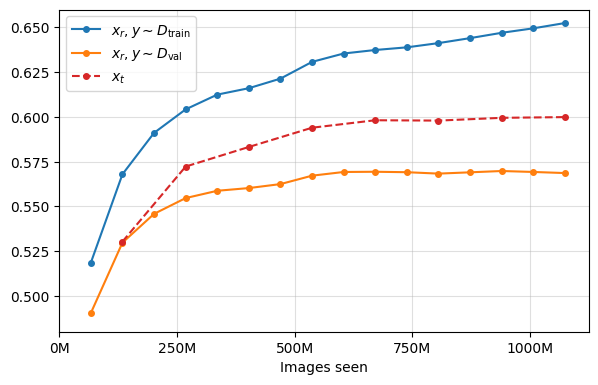

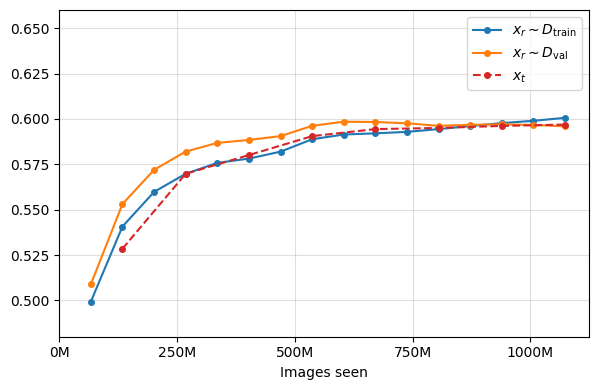

In [5]:
LABELS = {
    "xr_train_vs_train": r"$x_r, y \sim D_\mathrm{train}$",
    "xr_val_vs_train":   r"$x_r, y \sim D_\mathrm{val}$",
    "xt_vs_train":       r"$x_t$",
    "xt_stop18_vs_train": r"$x_t$",
    "xr_train_vs_val":   r"$x_r \sim D_\mathrm{train}$",
    "xr_val_vs_val":     r"$x_r \sim D_\mathrm{val}$",
    "xt_vs_val":         r"$x_t$",
    "xt_stop18_vs_val":  r"$x_t$",
}

COLORS = {
    "xr_train_vs_train":  "tab:blue",
    "xr_val_vs_train":    "tab:orange",
    "xt_vs_train":        "tab:green",
    "xt_stop18_vs_train": "tab:red",
    "xr_train_vs_val":    "tab:blue",
    "xr_val_vs_val":      "tab:orange",
    "xt_vs_val":          "tab:green",
    "xt_stop18_vs_val":   "tab:red",
}

LINESTYLES = {
    "xr_train_vs_train":  "-",
    "xr_val_vs_train":    "-",
    "xt_vs_train":        "--",
    "xt_stop18_vs_train": "--",
    "xr_train_vs_val":    "-",
    "xr_val_vs_val":      "-",
    "xt_vs_val":          "--",
    "xt_stop18_vs_val":   "--",
}

for split in ['train', 'val']:
    fig, ax = plt.subplots(figsize=(6, 4))
    for key in PROBE_KEYS:
        if f"vs_{split}" not in key or "xt_vs" in key:
            continue
            
        snaps, means = compute_mean_series(snap_data, key)
    
        if len(snaps) == 0:
            continue
            
        ax.plot(snaps, means,
                label=LABELS[key],
                color=COLORS[key],
                linestyle=LINESTYLES[key],
                marker="o", markersize=4)
    
    ax.set_xlabel("Images seen")
    # ax.set_ylabel("Avg. 1-NN cos-sim")
    # ax.set_title(f"{dataset}  {model_size}")
    ax.legend()
    fig.tight_layout()
    plt.grid(alpha=0.4)
    plt.ylim([0.48, 0.66])
    plt.xticks([0, 250000, 500000, 750000, 1000000], ['0M', '250M', '500M', '750M', '1000M'])
    if save_figs:
        plt.savefig(f"{figs_folder}/figs/eccv2026/1-nn_in64_edm2-s_{split}.png", dpi=200, bbox_inches='tight')
    plt.show()